In [1]:
! pip install --upgrade git+https://github.com/keras-team/keras-cv -q
! pip install -Uq keras

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import optimizers
import keras_cv
import numpy as np
from keras_cv import bounding_box
import resource
from keras_cv import visualization
import tqdm
import os
import json

In [3]:
with open('/kaggle/input/cocococo-dataset/export/_annotations.coco.json') as f:
  j = json.load(f)

In [4]:
class_mapping = {c['id']: c['name'] for c in j['categories']}
class_mapping

{0: 'obstacles',
 1: 'biker',
 2: 'car',
 3: 'pedestrian',
 4: 'trafficLight',
 5: 'trafficLight-Green',
 6: 'trafficLight-GreenLeft',
 7: 'trafficLight-Red',
 8: 'trafficLight-RedLeft',
 9: 'trafficLight-Yellow',
 10: 'trafficLight-YellowLeft',
 11: 'truck'}

In [5]:
base_dir="/kaggle/input/cocococo-dataset/export/"

In [6]:
def fix_filename(file_name):
    if not file_name.endswith(".jpg"):  # Ensure it ends with '.jpg'
        return file_name + ".jpg"
    return file_name

In [7]:
image_paths = [os.path.join(base_dir, fix_filename(d["file_name"])) for d in j["images"]]


In [8]:
classes = [[] for _ in image_paths]
bounding_boxes = [[] for _ in image_paths]

In [9]:
for a in j['annotations']:
  idx = a['image_id']
  classes[idx].append(a['category_id'])
  bounding_boxes[idx].append(a['bbox'])

In [10]:
no_annotations = [len(x) == 0 for x in classes]

In [11]:
len(image_paths)

29800

In [12]:
bbox = tf.ragged.constant(bounding_boxes)
classes = tf.ragged.constant(classes)
image_paths = tf.ragged.constant(image_paths)

data = tf.data.Dataset.from_tensor_slices((image_paths, classes, bbox))

In [13]:
smalldata = data.take(10_000)
val_data = smalldata.take(2_000)
train_data = smalldata.skip(2_000)

In [14]:
def load_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    return image


def load_dataset(image_path, classes, bbox):
    # Read Image
    image = load_image(image_path)
    bounding_boxes = {
        "classes": tf.cast(classes, dtype=tf.float32),
        "boxes": bbox,
    }
    return {
        "images": tf.cast(image, tf.float32), "bounding_boxes": bounding_boxes}

In [15]:
# Hyperparams
BATCH_SIZE = 4

In [16]:
augmenter = keras.Sequential(
    layers=[
        keras_cv.layers.RandomFlip(
            mode="horizontal", bounding_box_format="xywh"),
        keras_cv.layers.RandomShear(
            x_factor=0.2, y_factor=0.2, bounding_box_format="xywh"
        ),
        keras_cv.layers.JitteredResize(
            target_size=(640, 640),
            scale_factor=(0.75, 1.3),
            bounding_box_format="xywh"
        ),
    ]
)

# Create train dataset

In [17]:

train_ds = train_data.map(load_dataset, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(BATCH_SIZE * 4)
train_ds = train_ds.ragged_batch(BATCH_SIZE, drop_remainder=True)
train_ds = train_ds.map(augmenter, num_parallel_calls=tf.data.AUTOTUNE)

# Create validation dataset

In [18]:

resizing = keras_cv.layers.Resizing(
    640, 640, bounding_box_format="xywh", pad_to_aspect_ratio=True
)

val_ds = val_data.map(load_dataset, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.shuffle(BATCH_SIZE * 4)
val_ds = val_ds.ragged_batch(BATCH_SIZE, drop_remainder=True)
val_ds = val_ds.map(resizing, num_parallel_calls=tf.data.AUTOTUNE)

In [19]:
def visualize_dataset(inputs, value_range, rows, cols, bounding_box_format):
    inputs = next(iter(inputs.take(1)))
    images, bounding_boxes = inputs["images"], inputs["bounding_boxes"]
    visualization.plot_bounding_box_gallery(
        images,
        value_range=value_range,
        rows=rows,
        cols=cols,
        y_true=bounding_boxes,
        scale=5,
        font_scale=0.7,
        bounding_box_format=bounding_box_format,
        class_mapping=class_mapping,
    )

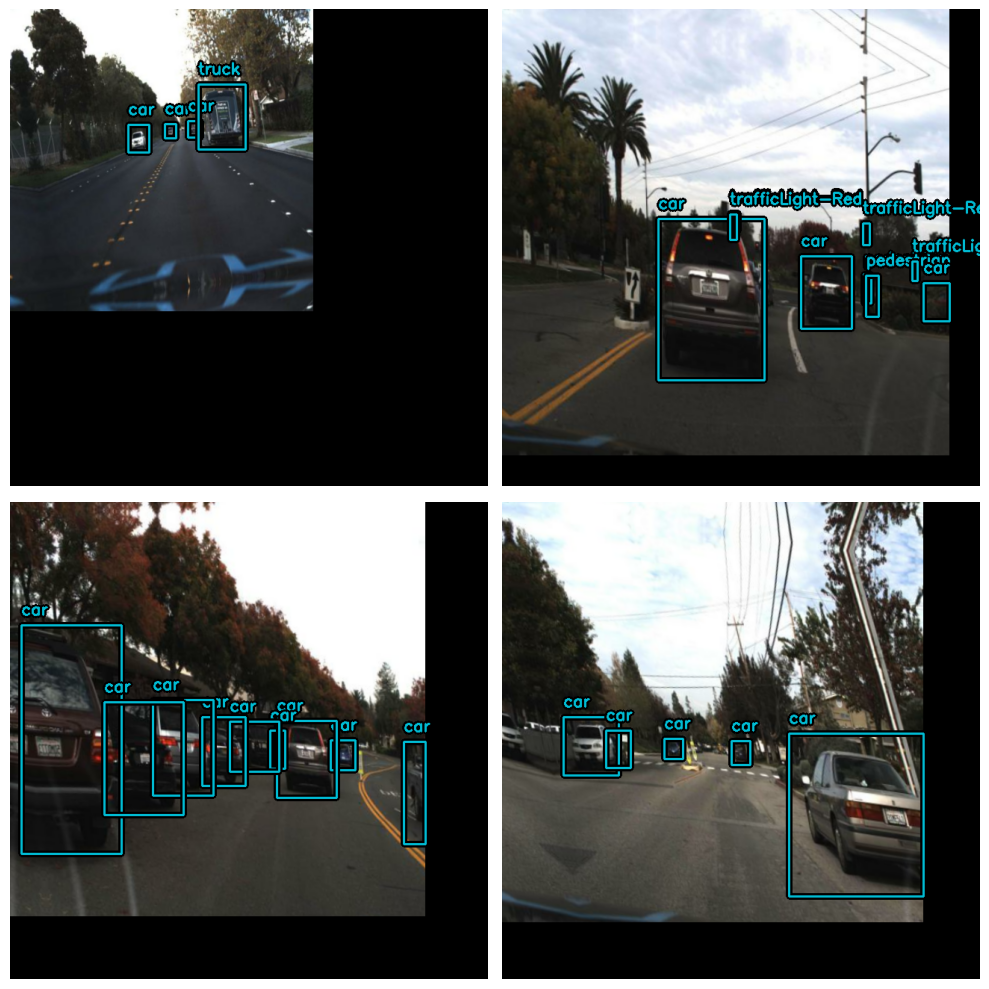

In [20]:
visualize_dataset(
    train_ds, bounding_box_format="xywh", value_range=(0, 255), rows=2, cols=2
)

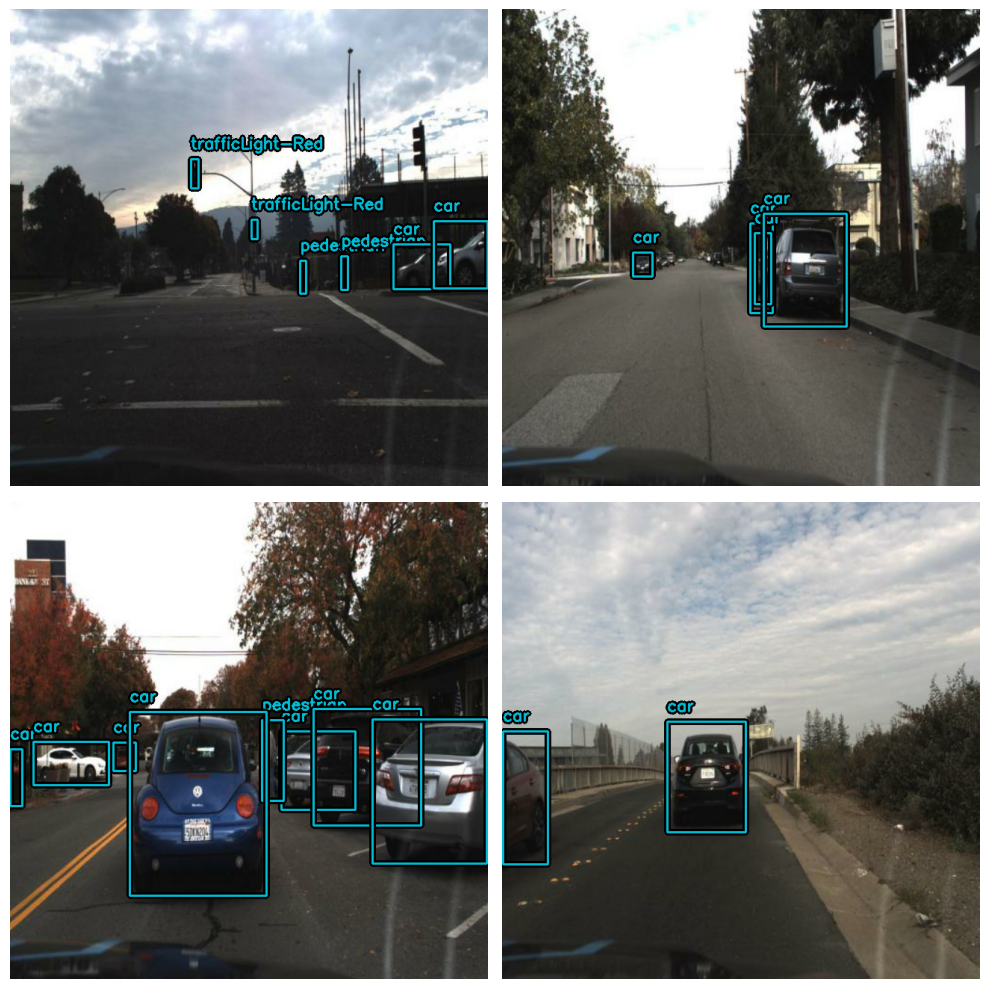

In [21]:
visualize_dataset(
    val_ds, bounding_box_format="xywh", value_range=(0, 255), rows=2, cols=2
)

In [22]:
def dict_to_tuple(inputs):
    return inputs["images"], bounding_box.to_dense(
        inputs["bounding_boxes"], max_boxes=32
    )


train_ds = train_ds.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [23]:
base_lr = 0.005

optimizer = keras.optimizers.SGD(learning_rate=base_lr, momentum=0.9, global_clipnorm=10.0)

In [24]:

model = keras_cv.models.RetinaNet.from_preset("resnet50_imagenet",num_classes=len(class_mapping),
        bounding_box_format="xywh")
model.compile(classification_loss="focal",box_loss="smoothl1",optimizer=optimizer)
model.summary()

Model: "retina_net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer) │ (None, None,      │          0 │ -                 │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, None,     │ 23,561,152 │ images[0][0]      │
│ (Functional)        │ None, 512),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 1024),      │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 2048)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_pyramid     │ [(None, None,     │  7,997,440 │ functional[0][0], │
│ (FeaturePyramid)    │ None, 256),       │            │ functional[0][1], │
│                     │ (None, None,      │            │ functional[0][2]  │
│                     │ None, 256),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 256),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 256),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 256)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction_head_1   │ (None, None,      │  1,853,220 │ feature_pyramid[… │
│ (PredictionHead)    │ None, 36)         │            │ feature_pyramid[… │
│                     │                   │            │ feature_pyramid[… │
│                     │                   │            │ feature_pyramid[… │
│                     │                   │            │ feature_pyramid[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction_head     │ (None, None,      │  2,019,180 │ feature_pyramid[… │
│ (PredictionHead)    │ None, 108)        │            │ feature_pyramid[… │
│                     │                   │            │ feature_pyramid[… │
│                     │                   │            │ feature_pyramid[… │
│                     │                   │            │ feature_pyramid[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, None, 4)   │          0 │ prediction_head_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, None, 4)   │          0 │ prediction_head_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, None, 4)   │          0 │ prediction_head_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, None, 4)   │          0 │ prediction_head_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_8 (Reshape) │ (None, None, 4)   │          0 │ prediction_head_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, None, 12)  │          0 │ prediction_head[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, None, 12)  │          0 │ prediction_head[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, None, 12)  │          0 │ prediction_head[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 35,430,992 (135.16 MB)

 Trainable params: 35,377,872 (134.96 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [25]:

history=model.fit(train_ds.take(200),validation_data=val_ds.take(200),epochs=10)

Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(4, 640, 640, 3))
  warnings.warn(msg)
/opt/conda/lib/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(4, 640, 640, 3))
  warnings.warn(msg)
I0000 00:00:1734362213.055167    1752 service.cc:145] XLA service 0x5cefca8e9190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1734362213.055284    1752 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1734362213.055293    1752 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1734362273.420181    1752 asm_compiler.cc:369] ptxas warning : Registers are spilled 

200/200 ━━━━━━━━━━━━━━━━━━━━ 247s 816ms/step - box_loss: 0.5978 - classification_loss: 0.6658 - loss: 1.2636 - val_box_loss: 0.4425 - val_classification_loss: 0.4337 - val_loss: 0.8761
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 156s 777ms/step - box_loss: 0.3939 - classification_loss: 0.3925 - loss: 0.7864 - val_box_loss: 0.3659 - val_classification_loss: 0.3824 - val_loss: 0.7483
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 157s 777ms/step - box_loss: 0.3427 - classification_loss: 0.3546 - loss: 0.6973 - val_box_loss: 0.3476 - val_classification_loss: 0.3171 - val_loss: 0.6647
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 157s 779ms/step - box_loss: 0.3101 - classification_loss: 0.3027 - loss: 0.6127 - val_box_loss: 0.3121 - val_classification_loss: 0.2851 - val_loss: 0.5971
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 157s 780ms/step - box_loss: 0.2841 - classification_loss: 0.2617 - loss: 0.5458 - val_box_loss: 0.3114 - val_classification_loss: 0.2690 - val_loss: 0.5804
Epoch 6/10
200/200 ━━━━━━━━━━━━

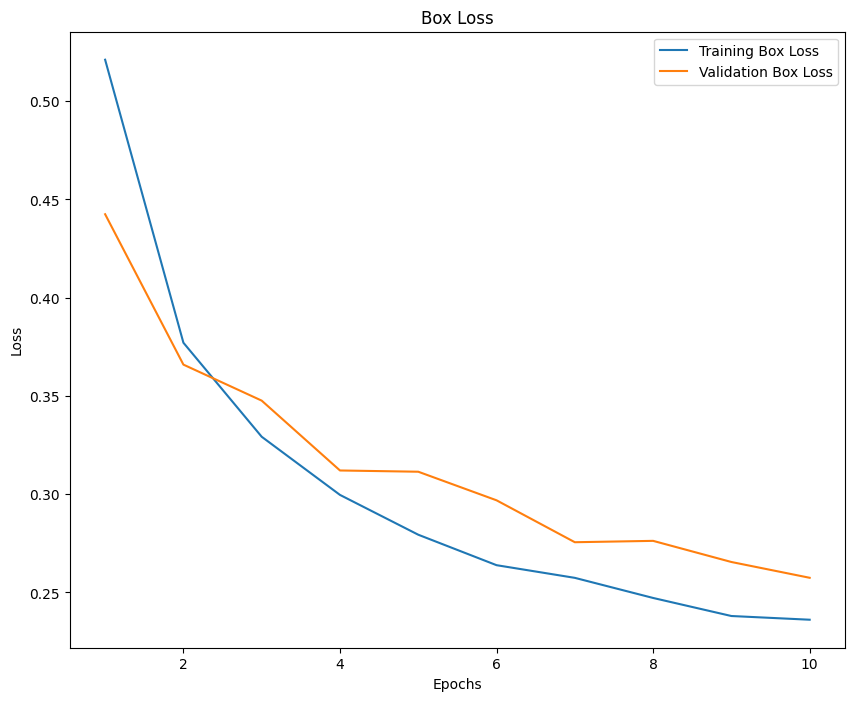

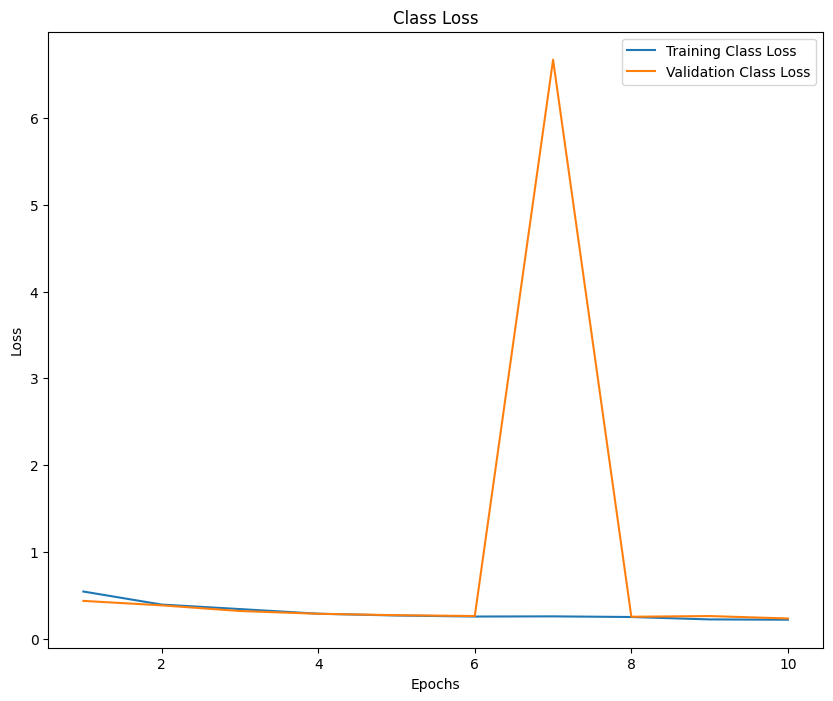

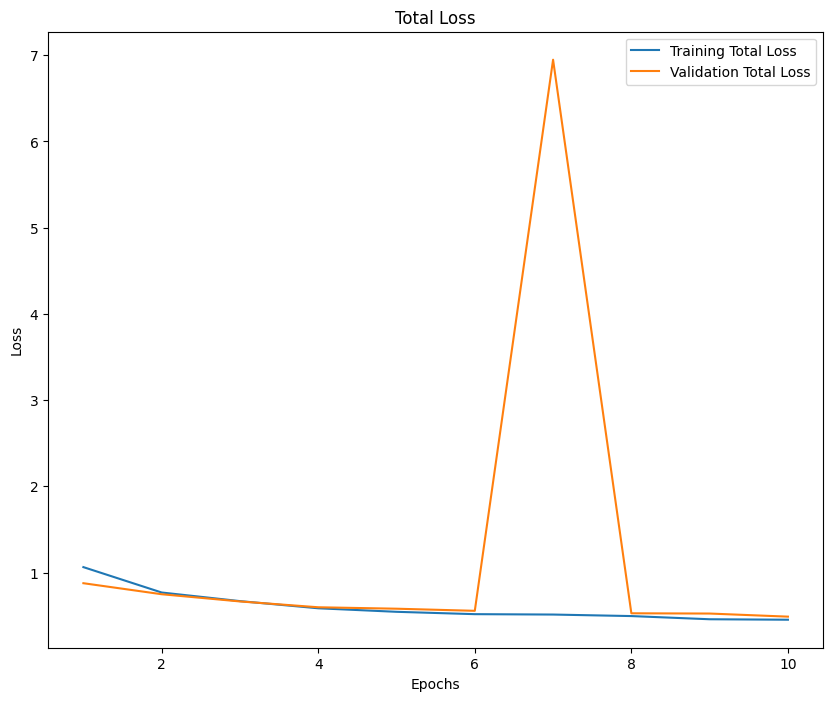

In [26]:

import matplotlib.pyplot as plt
epochs = range(1, len(history.history["loss"]) + 1)  

plt.figure(figsize=(10,8))

# Plot box loss
plt.plot(epochs, history.history["box_loss"], label="Training Box Loss")
plt.plot(epochs, history.history["val_box_loss"], label="Validation Box Loss")
plt.title("Box Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot class loss.
plt.figure(figsize=(10,8))
plt.plot(epochs, history.history["classification_loss"], label="Training Class Loss")
plt.plot(epochs, history.history["val_classification_loss"], label="Validation Class Loss")
plt.title("Class Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot total loss
plt.figure(figsize=(10,8))
plt.plot(epochs, history.history["loss"], label="Training Total Loss")
plt.plot(epochs, history.history["val_loss"], label="Validation Total Loss")
plt.title("Total Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


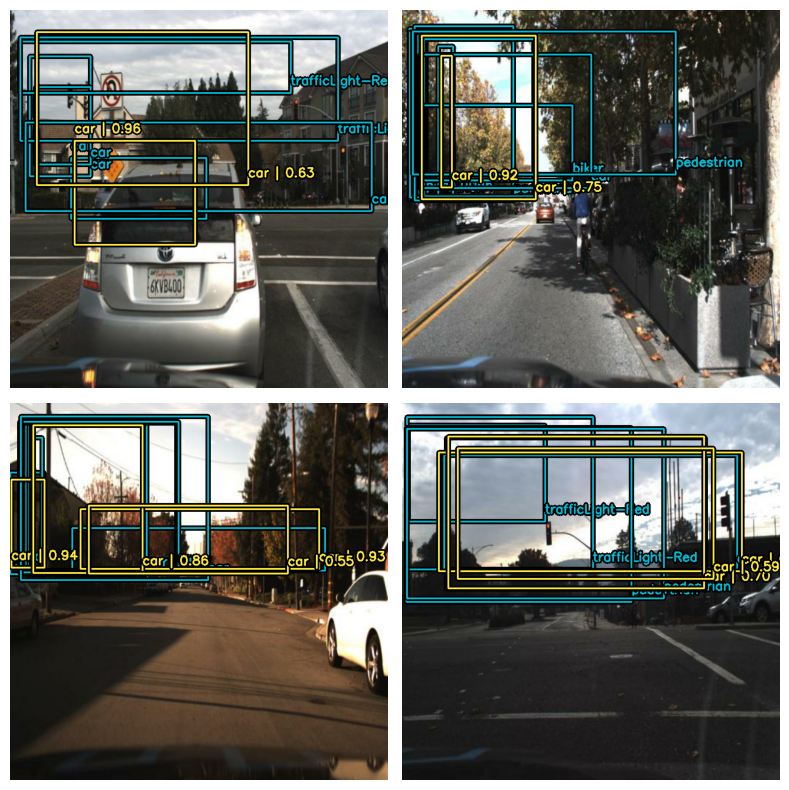

In [27]:
def visualize_detections(model, dataset, bounding_box_format):
    images, y_true = next(iter(dataset.take(1)))
    y_pred = model.predict(images)
    
    visualization.plot_bounding_box_gallery(
        images,
        value_range=(0, 255),
        bounding_box_format=bounding_box_format,
        y_true=y_true,
        y_pred=y_pred,
        scale=4,
        rows=2,
        cols=2,
        show=True,
        font_scale=0.7,
        class_mapping=class_mapping,
    )


visualize_detections(model, dataset=val_ds, bounding_box_format="xyxy")